<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/BasicML/BasicML/Backtesting_Framework(Vectorized).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = yf.download('AAPL', start='2015-01-01', end='2024-01-01', auto_adjust=False)['Adj Close']
df.columns = ['Close'] # Rename for simplicity

# 2. Define our Moving Average Windows
short_window = 50
long_window = 200

# 3. Calculate the Indicators
df['SMA_Short'] = df['Close'].rolling(window=short_window).mean()
df['SMA_Long'] = df['Close'].rolling(window=long_window).mean()

# 4. Generate the "Raw Signal"
# If Short > Long, put 1. Otherwise, put 0.
df['Signal'] = np.where(df['SMA_Short'] > df['SMA_Long'], 1, 0)

# Check the first few rows where a signal appears
df.tail()

[*********************100%***********************]  1 of 1 completed


,Close,SMA_Short,SMA_Long,Signal
Date,,,,
2023-12-22,191.788757,183.572863,176.609049,1
2023-12-26,191.243912,183.858869,176.832687,1
2023-12-27,191.342972,184.149428,177.047101,1
2023-12-28,191.768967,184.479572,177.253187,1
2023-12-29,190.728760,184.814833,177.452099,1


In [ ]:
# 5. Create the "Position" Column
# Shift the signal down by 1 day.
# Today's Position is determined by Yesterday's Signal.
df['Position'] = df['Signal'].shift(1)

# Drop the empty rows at the start (where SMAs were calculating)
df = df.dropna()

df[['Close', 'Signal', 'Position']].tail()

,Close,Signal,Position
Date,,,
2023-12-22,191.788757,1,1.0
2023-12-26,191.243912,1,1.0
2023-12-27,191.342972,1,1.0
2023-12-28,191.768967,1,1.0
2023-12-29,190.728760,1,1.0


In [ ]:
# 6. Calculate Daily Market Returns
df['Market_Ret'] = df['Close'].pct_change()

# 7. Calculate Strategy Returns (Gross)
# If Position is 1, we get the Market Return.
# If Position is 0, we get 0.
df['Strategy_Ret'] = df['Position'] * df['Market_Ret']

# 8. Calculate Transaction Costs
# We define a cost of 0.10% (10 basis points) per trade
cost_per_trade = 0.0010

# 'Trades' detects changes.
# 0 -> 1 is a Buy (diff is 1). 1 -> 0 is a Sell (diff is -1).
# .abs() makes them both positive because both cost money.
df['Trades'] = df['Position'].diff().abs()

# 9. Calculate Net Returns
# Net = Gross Return - (Number of Trades * Cost)
df['Net_Strategy_Ret'] = df['Strategy_Ret'] - (df['Trades'] * cost_per_trade)

# Fill any NaNs created by calculations with 0
df.fillna(0, inplace=True)

df.head()

,Close,SMA_Short,SMA_Long,Signal,Position,Market_Ret,Strategy_Ret,Trades,Net_Strategy_Ret
Date,,,,,,,,,
2015-10-16,24.929359,25.222927,27.085378,0,0.0,0.000000,0.0,0.0,0.0
2015-10-19,25.084269,25.205909,27.089611,0,0.0,0.006214,0.0,0.0,0.0
2015-10-20,25.542267,25.179193,27.099549,0,0.0,0.018258,0.0,0.0,0.0
2015-10-21,25.540022,25.180405,27.109464,0,0.0,-0.000088,-0.0,0.0,-0.0
2015-10-22,25.930668,25.181573,27.119681,0,0.0,0.015295,0.0,0.0,0.0


In [ ]:
# 10. Calculate Equity Curves (Cumulative Growth)
# We assume starting with $1. cumprod() compounds the returns.
df['Equity_Curve'] = (1 + df['Net_Strategy_Ret']).cumprod()
df['Benchmark_Curve'] = (1 + df['Market_Ret']).cumprod()

# 11. Calculate Sharpe Ratio
# Formula: (Average Daily Return / Daily Volatility) * Sqrt(252 trading days)
sharpe_ratio = (df['Net_Strategy_Ret'].mean() / df['Net_Strategy_Ret'].std()) * (252 ** 0.5)

# 12. Calculate Drawdown (The Pain)
# Find the highest peak so far
running_max = df['Equity_Curve'].cummax()
# Calculate percentage drop from that peak
df['Drawdown'] = (df['Equity_Curve'] / running_max) - 1
# Find the worst day
max_drawdown = df['Drawdown'].min()

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown * 100:.2f}%")

Sharpe Ratio: 0.88
Max Drawdown: -45.72%


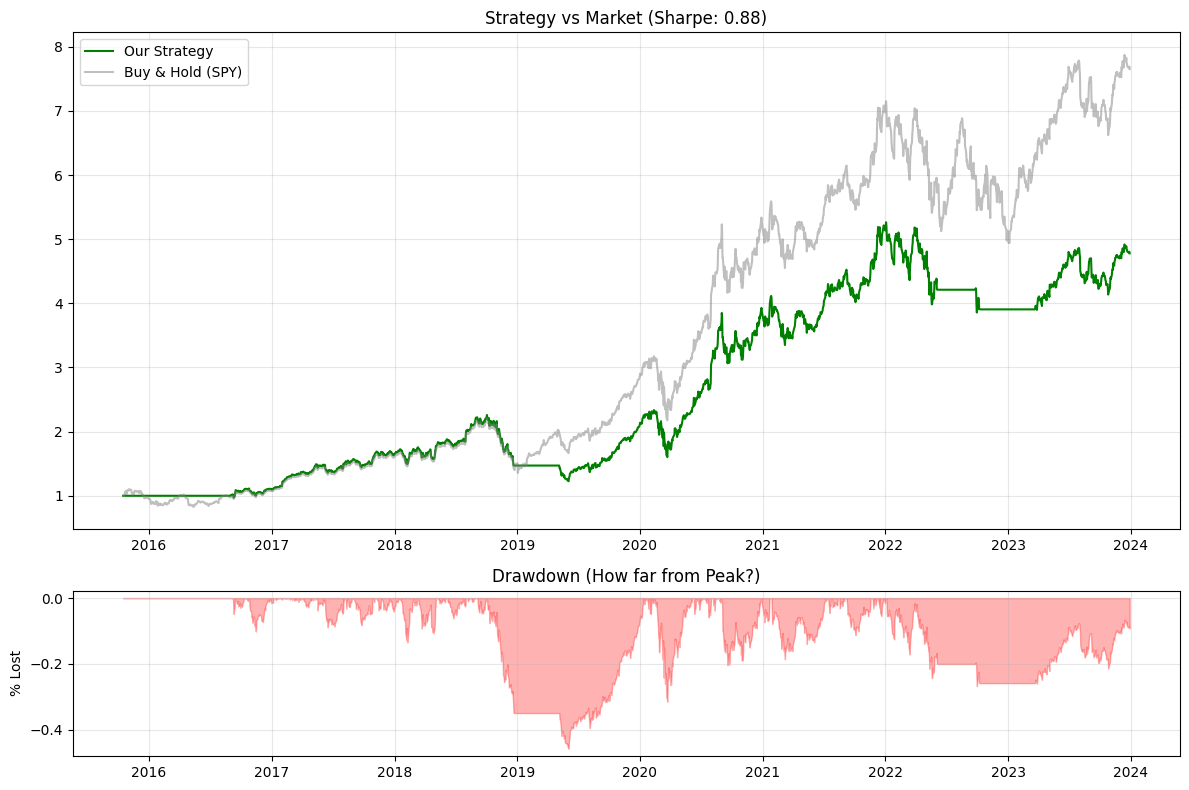

In [ ]:
# 13. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

# Chart 1: Performance
ax1.plot(df.index, df['Equity_Curve'], label='Our Strategy', color='green')
ax1.plot(df.index, df['Benchmark_Curve'], label='Buy & Hold (SPY)', color='gray', alpha=0.5)
ax1.set_title(f'Strategy vs Market (Sharpe: {sharpe_ratio:.2f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Chart 2: Drawdown (The Red Zone)
ax2.fill_between(df.index, df['Drawdown'], 0, color='red', alpha=0.3)
ax2.set_title('Drawdown (How far from Peak?)')
ax2.set_ylabel('% Lost')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

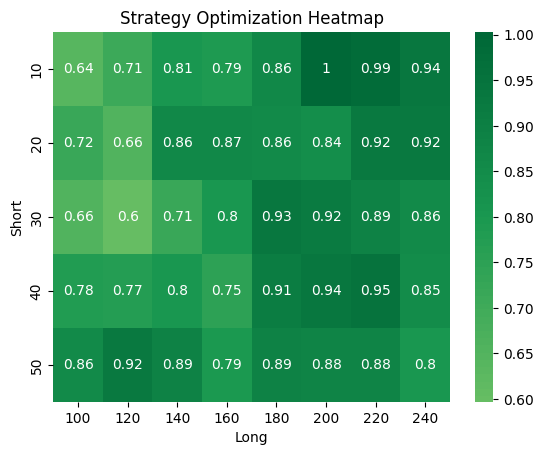

In [ ]:
# Define a function that runs everything we just wrote above
def get_sharpe(short_w, long_w, data):
    if short_w >= long_w: return np.nan # Invalid combo

    d = data.copy()
    # Fast calc
    d['Signal'] = np.where(d['Close'].rolling(short_w).mean() > d['Close'].rolling(long_w).mean(), 1, 0)
    d['Position'] = d['Signal'].shift(1)

    # Returns
    ret = d['Position'] * d['Close'].pct_change()
    # Cost (approximate for speed)
    trades = d['Position'].diff().abs()
    net_ret = ret - (trades * 0.0010)

    # Sharpe
    if net_ret.std() == 0: return 0
    return (net_ret.mean() / net_ret.std()) * (252 ** 0.5)

# Run the Loop
results = []
for s in range(10, 60, 10):      # Test Short: 10, 20, 30...
    for l in range(100, 250, 20): # Test Long: 100, 120, 140...
        score = get_sharpe(s, l, df)
        results.append({'Short': s, 'Long': l, 'Sharpe': score})

# Visualize as Heatmap
res_df = pd.DataFrame(results).pivot(index='Short', columns='Long', values='Sharpe')
sns.heatmap(res_df, annot=True, cmap='RdYlGn', center=0)
plt.title('Strategy Optimization Heatmap')
plt.show()